# 实验二参考答案：美国月度零售销售额的科研级可视化

> 对应讲次：第2讲 数据高阶可视化 × AI 辅助表达  
> 实验数据：`美国零售销售额.csv`（FRED `RSXFS` 的 2010—2024 教学冻结子集，180 条月度记录）  
> 课堂案例仍使用全球气温数据；本 Notebook 只服务于实验二。  
> AI 角色：设计顾问 —— 生成初稿、按约束优化、人工审查和局部微调。


## 环境配置与数据加载

本 Notebook 从 `第2讲/实验参考答案/` 运行时，会自动定位同级的 `实验二/` 数据目录，并把生成图表保存到 `第2讲/实验二/output/`。这样不会覆盖课堂案例已有的 `第2讲/output/` 文件。


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# 在不同启动目录下自动定位实验二数据目录
candidates = [
    Path.cwd() / '第2讲' / '实验二',
    Path.cwd().parent / '实验二',
    Path.cwd() / '实验二',
]
DATA_DIR = next((p for p in candidates if (p / '美国零售销售额.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('未找到 美国零售销售额.csv，请确认 Notebook 位于第2讲/实验参考答案目录。')

DATA_FILE = DATA_DIR / '美国零售销售额.csv'
OUTPUT_DIR = DATA_DIR / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.sans-serif': ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Wong (2011) 色盲友好配色
WONG = {
    'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73',
    'pink': '#CC79A7', 'lightblue': '#56B4E9', 'red': '#D55E00', 'yellow': '#F0E442'
}
print(f'数据目录：{DATA_DIR}')
print(f'输出目录：{OUTPUT_DIR}')


数据目录：/Users/jafekin/Documents/Python进阶课课件及案例开发/课程资料v3/第2讲/实验二
输出目录：/Users/jafekin/Documents/Python进阶课课件及案例开发/课程资料v3/第2讲/实验二/output


In [2]:
# 加载教学冻结数据
sales = pd.read_csv(DATA_FILE, parse_dates=['日期'])
sales = sales.sort_values('日期').reset_index(drop=True)
sales['零售销售额_十亿美元'] = sales['零售销售额_百万美元'] / 1000
month_labels = {i: f'{i}月' for i in range(1, 13)}
sales['月份标签'] = sales['月份'].map(month_labels)
sales['时期'] = pd.cut(
    sales['年份'],
    bins=[2009, 2014, 2019, 2024],
    labels=['2010—2014', '2015—2019', '2020—2024'],
    include_lowest=True,
)

print(f'数据形状：{sales.shape}')
print(f'时间范围：{sales["日期"].min():%Y-%m} 至 {sales["日期"].max():%Y-%m}')
print(f'销售额范围：{sales["零售销售额_百万美元"].min():,.0f}—{sales["零售销售额_百万美元"].max():,.0f} 百万美元')
display(sales.head())


数据形状：(180, 8)
时间范围：2010-01 至 2024-12
销售额范围：302,310—621,713 百万美元


,日期,年份,月份,零售销售额_百万美元,年月,零售销售额_十亿美元,月份标签,时期
0,2010-01-01,2010,1,302325,2010-01,302.325,1月,2010—2014
1,2010-02-01,2010,2,302310,2010-02,302.310,2月,2010—2014
2,2010-03-01,2010,3,309525,2010-03,309.525,3月,2010—2014
3,2010-04-01,2010,4,312143,2010-04,312.143,4月,2010—2014
4,2010-05-01,2010,5,309158,2010-05,309.158,5月,2010—2014


In [3]:
# 公共汇总数据
sales['12个月移动平均'] = sales['零售销售额_百万美元'].rolling(window=12, min_periods=6).mean()
annual = (sales.groupby('年份', as_index=False)['零售销售额_百万美元']
          .mean()
          .rename(columns={'零售销售额_百万美元': '年度平均销售额_百万美元'}))
annual['年度平均销售额_十亿美元'] = annual['年度平均销售额_百万美元'] / 1000

monthly_mean = (sales.groupby(['月份', '月份标签'], as_index=False)['零售销售额_百万美元']
                .mean()
                .sort_values('月份'))
monthly_mean['月度平均销售额_十亿美元'] = monthly_mean['零售销售额_百万美元'] / 1000

print(f'年度汇总：{len(annual)} 年')
print(f'最高年度平均销售额：{annual.loc[annual["年度平均销售额_百万美元"].idxmax(), "年份"]} 年')
display(annual.head())


年度汇总：15 年
最高年度平均销售额：2024 年


,年份,年度平均销售额_百万美元,年度平均销售额_十亿美元
0,2010,311662.750000,311.662750
1,2011,335087.583333,335.087583
2,2012,351132.583333,351.132583
3,2013,364618.250000,364.618250
4,2014,379078.666667,379.078667


## 任务1：Matplotlib 基础可视化（20分）

### 1.1 月度销售额趋势图：原始曲线 + 12 个月移动平均

原始曲线保留月度波动，12 个月移动平均用于观察较平滑的长期趋势。标注 2020 年附近的变化只能提示时间上的异常波动，不能单独证明其因果来源。


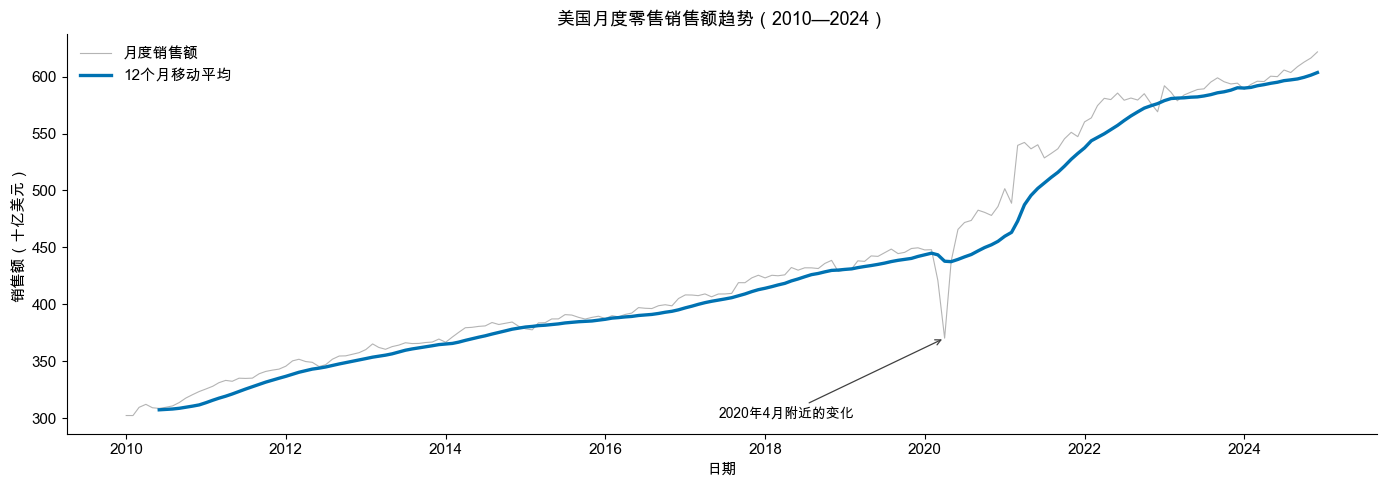

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sales['日期'], sales['零售销售额_十亿美元'],
        color='0.55', linewidth=0.8, alpha=0.65, label='月度销售额')
ax.plot(sales['日期'], sales['12个月移动平均'] / 1000,
        color=WONG['blue'], linewidth=2.4, label='12个月移动平均')

# 标出 2020 年 4 月的明显变化，仅作为时间标记
special = sales.loc[sales['日期'].eq(pd.Timestamp('2020-04-01'))].iloc[0]
ax.annotate('2020年4月附近的变化',
            xy=(special['日期'], special['零售销售额_十亿美元']),
            xytext=(pd.Timestamp('2017-06-01'), special['零售销售额_十亿美元'] - 70),
            arrowprops=dict(arrowstyle='->', color='0.25', lw=0.9),
            fontsize=10)

ax.set_title('美国月度零售销售额趋势（2010—2024）')
ax.set_xlabel('日期')
ax.set_ylabel('销售额（十亿美元）')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=False, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task1_trend.png', dpi=300, bbox_inches='tight')
plt.show()


### 1.2 各年度平均销售额柱状图

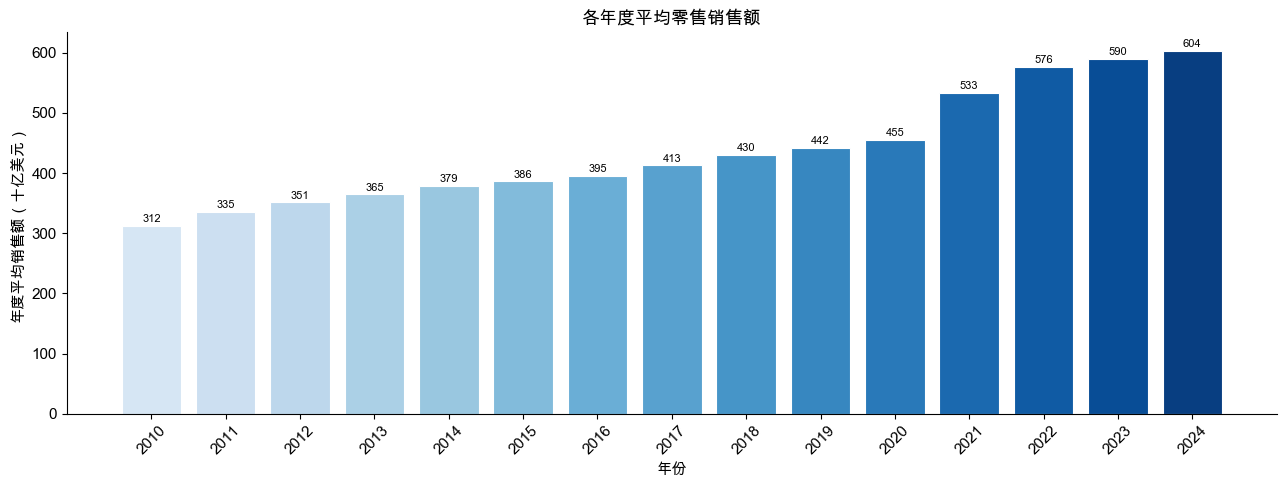

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = sns.color_palette('Blues', n_colors=len(annual) + 2)[2:]
bars = ax.bar(annual['年份'].astype(str), annual['年度平均销售额_十亿美元'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, value in zip(bars, annual['年度平均销售额_十亿美元']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 3,
            f'{value:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_title('各年度平均零售销售额')
ax.set_xlabel('年份')
ax.set_ylabel('年度平均销售额（十亿美元）')
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task1_annual.png', dpi=300, bbox_inches='tight')
plt.show()


### 1.3 月份季节性均值图

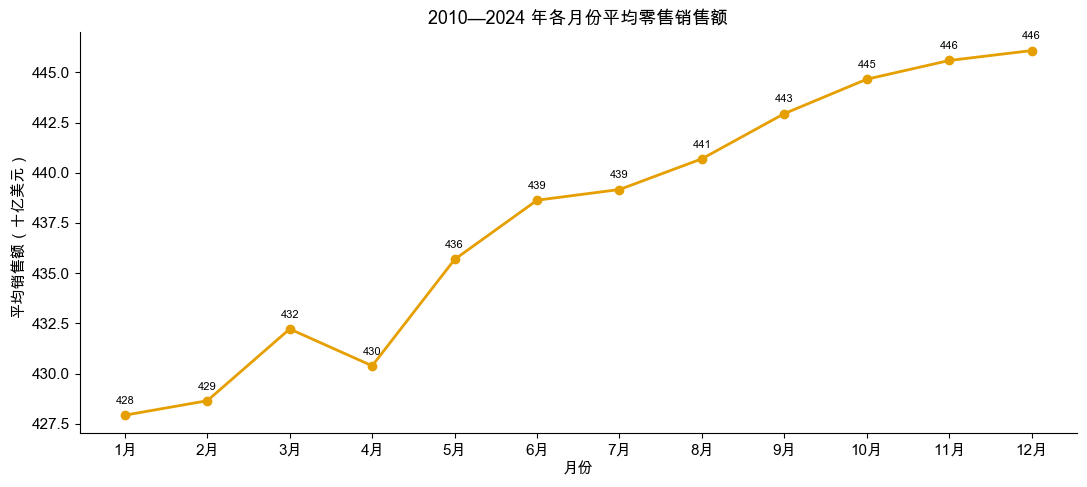

月度均值最高：12月
月度均值最低：1月


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(monthly_mean['月份'], monthly_mean['月度平均销售额_十亿美元'],
        marker='o', markersize=6, linewidth=2, color=WONG['orange'])
for _, row in monthly_mean.iterrows():
    ax.annotate(f'{row["月度平均销售额_十亿美元"]:.0f}',
                (row['月份'], row['月度平均销售额_十亿美元']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)

ax.set_title('2010—2024 年各月份平均零售销售额')
ax.set_xlabel('月份')
ax.set_ylabel('平均销售额（十亿美元）')
ax.set_xticks(range(1, 13), [f'{i}月' for i in range(1, 13)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task1_monthly_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'月度均值最高：{monthly_mean.loc[monthly_mean["月度平均销售额_十亿美元"].idxmax(), "月份标签"]}')
print(f'月度均值最低：{monthly_mean.loc[monthly_mean["月度平均销售额_十亿美元"].idxmin(), "月份标签"]}')


## 任务2：Seaborn 高阶探索（25分）

### 2.1 热力图：月份 × 年份

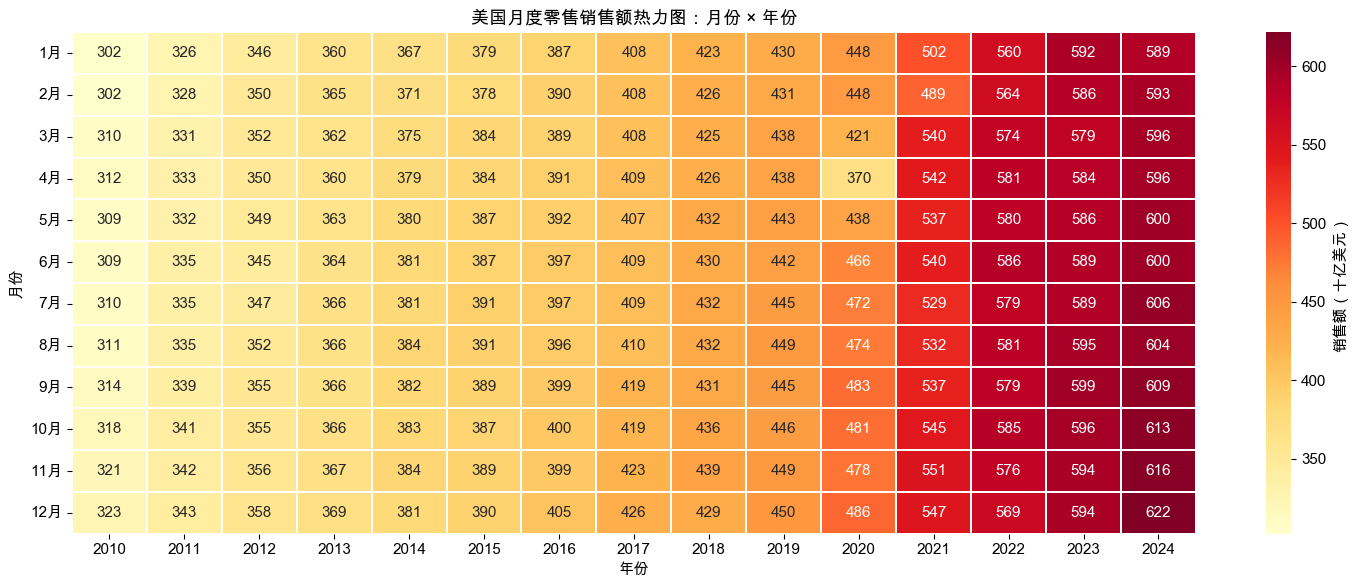

In [7]:
heatmap_data = (sales.pivot(index='月份', columns='年份', values='零售销售额_十亿美元')
                .reindex(range(1, 13)))

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.25, linecolor='white', cbar_kws={'label': '销售额（十亿美元）'}, ax=ax)
ax.set_title('美国月度零售销售额热力图：月份 × 年份')
ax.set_xlabel('年份')
ax.set_ylabel('月份')
ax.set_yticklabels([f'{i}月' for i in range(1, 13)], rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task2_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### 2.2 分时期小提琴图：2010—2014、2015—2019、2020—2024

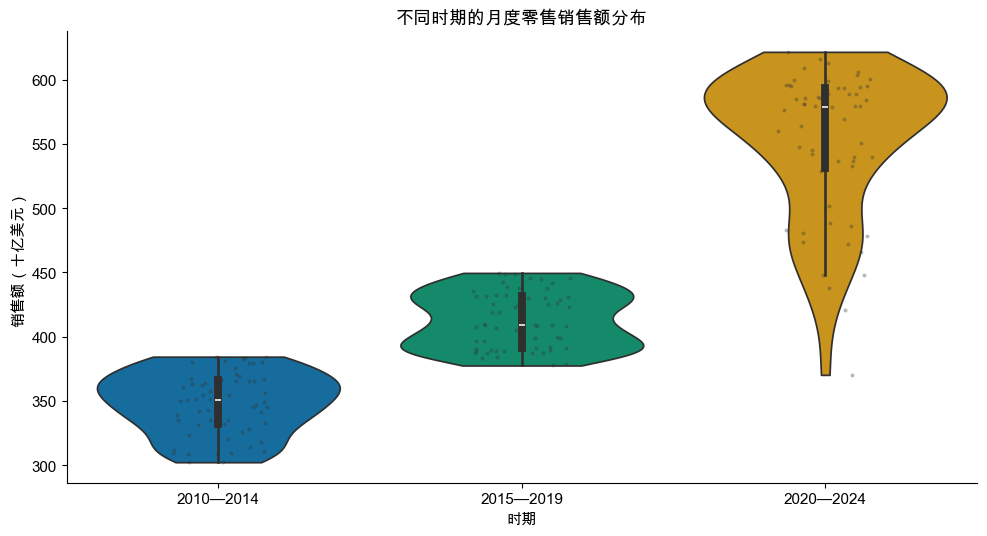

In [8]:
period_order = ['2010—2014', '2015—2019', '2020—2024']
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.violinplot(data=sales, x='时期', y='零售销售额_十亿美元', order=period_order,
               hue='时期', palette=[WONG['blue'], WONG['green'], WONG['orange']],
               inner='box', cut=0, legend=False, ax=ax)
sns.stripplot(data=sales, x='时期', y='零售销售额_十亿美元', order=period_order,
              color='0.2', alpha=0.35, size=2.8, jitter=0.16, ax=ax)
ax.set_title('不同时期的月度零售销售额分布')
ax.set_xlabel('时期')
ax.set_ylabel('销售额（十亿美元）')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task2_violin.png', dpi=300, bbox_inches='tight')
plt.show()


### 2.3 FacetGrid：三个时期的月份季节性

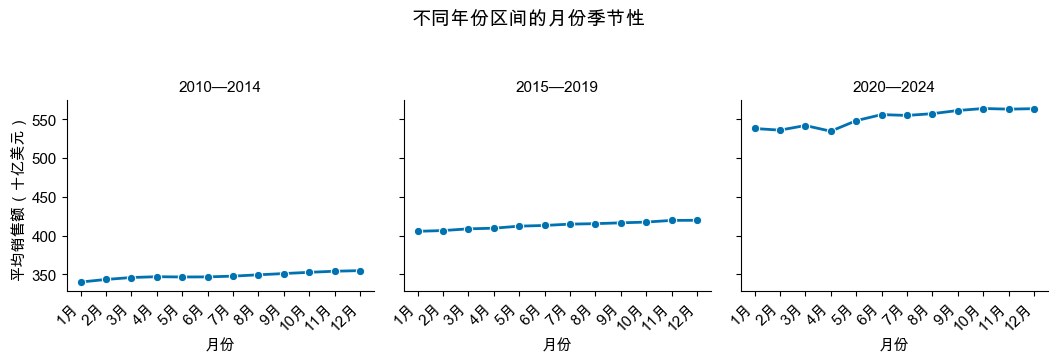

In [9]:
facet_data = (sales.groupby(['时期', '月份'], observed=True, as_index=False)['零售销售额_十亿美元']
              .mean())

g = sns.FacetGrid(facet_data, col='时期', col_order=period_order,
                  height=3.4, aspect=1.05, sharey=True,
                  palette=[WONG['blue'], WONG['green'], WONG['orange']])
g.map_dataframe(sns.lineplot, x='月份', y='零售销售额_十亿美元',
                marker='o', linewidth=2, color=WONG['blue'])
g.set_axis_labels('月份', '平均销售额（十亿美元）')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f'{i}月' for i in range(1, 13)], rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
g.figure.suptitle('不同年份区间的月份季节性', y=1.06, fontsize=14)
g.figure.tight_layout()
g.figure.savefig(OUTPUT_DIR / 'task2_facet.png', dpi=300, bbox_inches='tight')
plt.show()


## 任务3：科研单栏风格图表（30分）

下面的示例以 3.5 inch 宽度输出 PNG 与 PDF。置信区间带使用 12 个月滚动窗口的标准误差构造，是展示移动平均不确定性的近似方法；它并不消除时间序列自相关等统计限制。


### 3.1 统计比较：2010—2019 vs 2020—2024 年度平均值

In [10]:
early = annual.loc[annual['年份'].between(2010, 2019), '年度平均销售额_百万美元']
recent = annual.loc[annual['年份'].between(2020, 2024), '年度平均销售额_百万美元']
t_stat, p_value = stats.ttest_ind(early, recent, equal_var=False)

if p_value < 0.001:
    sig = '***'
elif p_value < 0.01:
    sig = '**'
elif p_value < 0.05:
    sig = '*'
else:
    sig = 'ns'

summary = pd.DataFrame({
    '2010—2019': [len(early), early.mean(), early.std(ddof=1)],
    '2020—2024': [len(recent), recent.mean(), recent.std(ddof=1)],
}, index=['样本量（年度）', '均值（百万美元）', '标准差'])
display(summary.round(2))
print(f'Welch t = {t_stat:.3f}, p = {p_value:.3e}, 显著性 = {sig}')
print('解释提示：这是对年度平均值的描述性比较，不应据此写出因果结论。')


,2010—2019,2020—2024
样本量（年度）,10.00,5.00
均值（百万美元）,380786.67,551585.83
标准差,41444.66,60076.64


Welch t = -5.714, p = 1.259e-03, 显著性 = **
解释提示：这是对年度平均值的描述性比较，不应据此写出因果结论。


### 3.2 主图：原始月度序列 + 移动平均 + 近似 95% 置信区间

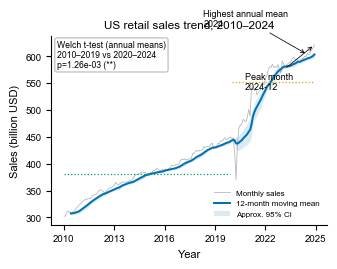

已保存：fig_nature.pdf 与 fig_nature.png
规格：3.5 inch 宽 | 300 dpi | Wong 色盲友好配色 | 左下坐标轴


In [11]:
plot_data = sales.set_index('日期').copy()
rolling_mean = plot_data['零售销售额_百万美元'].rolling(window=12, min_periods=6).mean()
rolling_std = plot_data['零售销售额_百万美元'].rolling(window=12, min_periods=6).std()
rolling_n = plot_data['零售销售额_百万美元'].rolling(window=12, min_periods=6).count()
ci_half_width = 1.96 * rolling_std / np.sqrt(rolling_n)
ci_lower = (rolling_mean - ci_half_width) / 1000
ci_upper = (rolling_mean + ci_half_width) / 1000

max_month = sales.loc[sales['零售销售额_百万美元'].idxmax()]
max_year = annual.loc[annual['年度平均销售额_百万美元'].idxmax()]

fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.plot(plot_data.index, plot_data['零售销售额_百万美元'] / 1000,
        color='0.6', linewidth=0.55, alpha=0.75, label='Monthly sales')
ax.plot(plot_data.index, rolling_mean / 1000,
        color=WONG['blue'], linewidth=1.45, label='12-month moving mean')
ax.fill_between(plot_data.index, ci_lower, ci_upper,
                color=WONG['blue'], alpha=0.15, linewidth=0,
                label='Approx. 95% CI')

# 两个时期的年度均值水平线
ax.hlines(early.mean() / 1000, pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-01'),
          color=WONG['green'], linestyle=':', linewidth=0.9)
ax.hlines(recent.mean() / 1000, pd.Timestamp('2020-01-01'), pd.Timestamp('2024-12-01'),
          color=WONG['orange'], linestyle=':', linewidth=0.9)

ax.annotate(f'Peak month\n{max_month["日期"]:%Y-%m}',
            xy=(max_month['日期'], max_month['零售销售额_十亿美元']),
            xytext=(-50, -32), textcoords='offset points', fontsize=6.5,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.55))
ax.annotate(f'Highest annual mean\n{int(max_year["年份"])}',
            xy=(pd.Timestamp(f'{int(max_year["年份"])}-07-01'), max_year['年度平均销售额_十亿美元']),
            xytext=(-75, 20), textcoords='offset points', fontsize=6.5,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.55))

ax.text(0.02, 0.98, f'Welch t-test (annual means)\n2010–2019 vs 2020–2024\np={p_value:.2e} ({sig})',
        transform=ax.transAxes, va='top', fontsize=6.2,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.75', alpha=0.9))

ax.set_title('US retail sales trend, 2010–2024', fontsize=8.5)
ax.set_xlabel('Year', fontsize=8)
ax.set_ylabel('Sales (billion USD)', fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=5.8, frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_nature.pdf', dpi=300)
plt.savefig(OUTPUT_DIR / 'fig_nature.png', dpi=300)
plt.show()
print('已保存：fig_nature.pdf 与 fig_nature.png')
print('规格：3.5 inch 宽 | 300 dpi | Wong 色盲友好配色 | 左下坐标轴')


### 发表级排版自查

| 检查项 | 要求 | 参考答案状态 |
|--------|------|:---:|
| 图片宽度 | 3.5 inch | OK |
| 分辨率 | 300 dpi | OK |
| 背景 | 白底、无不必要网格 | OK |
| 字体 | Arial 或系统无衬线字体 | OK（含回退） |
| 轴标签字号 | 约 8 pt | OK |
| 配色 | Wong 2011 色盲友好 | OK |
| 坐标轴 | 左、下可见，右、上隐藏 | OK |
| 输出格式 | PDF + PNG | OK |


## 任务4：AI 辅助三轮迭代（25分）

选择任务3主图，因为它包含时间序列、移动平均、置信区间、标注和统计比较，适合展示“先生成—再约束—最后局部微调”的过程。以下内容可作为实验报告中的过程记录示例；实际提交时应附上自己在 CodeBuddy 中的截图和人工审查结论。


### Round 1 — 氛围提示

```text
请用美国零售销售额.csv画一张有科研感的月度零售销售额趋势图，
突出长期变化和季节性，使用清晰的折线图。
```

**预期 AI 输出**：通常能得到原始折线图，可能加上移动平均，但往往遗漏不确定性、统计比较、尺寸和输出文件规格。

**人工审查重点**：数据文件路径是否正确、单位是否写成百万/十亿美元、横轴日期是否拥挤、是否把时间变化误写成因果结论。


### Round 2 — 约束提示

```text
在上一版基础上优化：
1. 叠加12个月移动平均线和近似95%置信区间带；
2. 标注最高销售额月份和最高年度平均值年份；
3. 对2010—2019与2020—2024年度均值做Welch t检验，并报告p值；
4. 使用Wong色盲友好配色；
5. 设置3.5 inch宽、300 dpi、约8 pt字体，输出PNG和PDF；
6. 去掉顶部和右侧边框，不使用不必要网格；
7. 不要把名义销售额增长解释为实际消费量增长。
```

**预期改进**：图表从“能画出来”提升为“可以进入研究报告的单栏图”，但仍需要人工核查统计限制与标注位置。


### Round 3 — Inline Edit 微调

- **微调 1**：`Cmd+K` → “把 Peak month 注释向左下移动，避免遮挡移动平均线。”
- **微调 2**：`Cmd+K` → “将置信区间 alpha 从 0.15 改为 0.12，减少对原始数据的遮挡。”
- **可选微调**：`Cmd+K` → “将横轴主刻度改为每三年一次，并确保年份标签不重叠。”

**人工审查结论示例**：局部微调应解决具体的视觉问题，而不是无目的地重写整段代码；每次修改后都要重新运行并核对图例、数据点与文件输出。


### Round 1 vs Round 3 对比

| 维度 | Round 1 | Round 3 |
|------|---------|---------|
| 信息传达 | 多为单一趋势线 | 原始序列 + 移动平均 + CI + 统计比较 + 关键标注 |
| 视觉美观 | 默认配色和字号 | Wong 配色、单栏尺寸、简洁边框 |
| 科研规范 | 常缺少输出规格与统计限制 | 明确尺寸、dpi、格式与解释边界 |
| 代码维护 | 快速生成但容易遗漏约束 | 分步骤构建，变量含义清晰 |

**Prompt 设计策略心得**：先用 Round 1 让 AI 建立图表框架，再在 Round 2 用可检查的约束逐条收紧需求，最后在 Round 3 处理只有实际运行和目视才会发现的局部问题。AI 给出的是候选实现，不是结论；数据路径、单位、时间排序、统计假设和因果表述必须由人复核。


## 思考题参考答案

### 1. AI 生成的配色是否色盲友好？如何验证？

AI 的默认配色不一定色盲友好，尤其要避免只靠红绿区分数据系列。可采用 Wong 2011 的常用色盲友好配色；再通过灰度预览、色盲模拟器或线型/标记冗余编码检查不同系列是否仍能区分。验证时不能只看颜色名称，还要检查透明度叠加后的实际显示效果。

### 2. 误差棒（errorbar）与置信区间（fill_between）分别适合什么场景？

误差棒适合离散的汇总点，例如每年的均值及其标准差/标准误；`fill_between` 适合连续时间序列，例如移动平均周围的不确定性带。无论使用哪一种，都必须在图注或正文中说明误差量的定义：标准差、标准误还是置信区间不能混用。

### 3. 双轴图（twinx）为什么容易产生误导？如何避免？

双轴图可以任意改变两个 Y 轴的范围，使不相关的曲线看起来同步，因此容易造成相关性或因果性的错觉。优先使用标准化后的单轴图、上下分面图或散点图；若确实需要双轴图，应清楚标注单位、范围和比较目的，不能以视觉同步暗示因果关系。


## 运行结果检查

运行全部单元格后，`第2讲/实验二/output/` 应包含：

- `task1_trend.png`
- `task1_annual.png`
- `task1_monthly_seasonality.png`
- `task2_heatmap.png`
- `task2_violin.png`
- `task2_facet.png`
- `fig_nature.png`
- `fig_nature.pdf`

任务4的三张截图由学生在 AI 工具中实际生成和保存，不由本参考答案自动伪造。
